# DYNAP-SE1 Excitatory/Inhibitory Network Experiment

This notebook builds a four-population excitatory/inhibitory network on a DYNAP-SE1 device, programs FPGA spike generators, records spikes, and plots the resulting network activity.

**Notebook flow**
1. Import packages and connect to the DYNAP-SE1 board.
2. Define network connection probabilities.
3. Build the excitatory and inhibitory populations.
4. Load chip/core parameters.
5. Program FPGA spike generators.
6. Run the experiment and collect spikes.
7. Plot activity and optionally save/reset parameters.


In [1]:
# =============================================================================
# 1. Imports and setup
# =============================================================================
import os
import subprocess

os.environ["LIBGL_ALWAYS_INDIRECT"] = "1"

import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image

# Project-specific utilities. The parent directory contains helper modules.
sys.path.append('..')

import samna
import samna.dynapse1 as dyn1
import dynapse1utils as ut
import params

from netgen import Neuron, NetworkGenerator
from params import set_params


In [2]:
# =============================================================================
# 2. Connect to the DYNAP-SE1 board
# =============================================================================

# Open the DYNAP-SE1 board and retrieve a Dynapse1Model instance.
#
# The specific-device utility is used here because remote setups such as Zemo
# may expose more than one attached board. Change `device_id` if a different
# board should be selected.
#model, _ = ut.open_specific_device_in_sequence(device_id=1)

# alternative:
model, gui_process = ut.open_dynapse1(gui=False)


[0]:  Bus 1 Device 6 Dynapse1DevKit serial_number 00000033
0 Dynapse1Wrapper created! libcaer init...
Selected device: 00000033
Sender port: tcp://0.0.0.0:35675
Receiver port: tcp://0.0.0.0:42835
Opened device name: Dynapse1DevKit
SamnaNode ID: 1
PythonNode ID: 2
Clearing chip 0... DONE.
Clearing chip 1... DONE.
Clearing chip 2... DONE.
Clearing chip 3... DONE.


In [3]:
api = model.get_dynapse1_api()

CHIP_ID = 0
E_CORE_ID =0
I_CORE_ID = 2
CORE_CAPACITY = 256

In [515]:
HUN = True
BASIC_PARAMS = False
EX_INDIVIDUAL_PARAMS = False
IN_INDIVIDUAL_PARAMS = False
PERFECT = False
REFERENCE = False
MATCH_TO = 0
PARAMS_SAVE = False

NOISE_FREQUENCY = 0 #200
NOISE_COINCIDENCE_WINDOW_PERCENT = 10

CYCLE = False

In [5]:
def generate_poisson_spikes(rate, duration, start = 0):
    """
    Generate spike times for a neuron with a constant firing rate using a Poisson process.
    
    Parameters:
    rate (float): Firing rate (spikes per second).
    duration (float): Duration of the simulation (seconds).
    start (float): Start time of the simulation in seconds (default=0).
    
    Returns:
    spike_times (NDArray[Any]): Array of spike times.
    """
    spike_times = np.array([])
    t = start
    
    while t < duration and rate > 0:
        # Generate the next spike interval
        interval = -np.log(np.random.rand()) / rate
        t += interval
        
        if t < duration:
            spike_times = np.append(spike_times, t)
    
    return spike_times

In [6]:
# =============================================================================
# 3. Load neuron and synapse parameters
# =============================================================================
# Option B: load parameters from a text file/profile.
# The profile name below should match the parameter file expected by the helper.
if HUN == True:
    ut.set_parameters_in_txt_file(model, 'hun')
    time.sleep(2)  # Short delay to ensure parameters are set before proceeding.


# Option A: use the parameter-setting helper from params.py.
# Uncomment if this is the preferred parameter source.
if BASIC_PARAMS == True:
    set_params(model)


if PERFECT == True:
    ut.set_parameters_in_txt_file(model, 'working_both')


In [516]:
# =============================================================================
# 4. Network connection probabilities
# =============================================================================

# Probability of excitatory-to-excitatory recurrent connections.
p_E_E = 0.9

# Probability of excitatory-to-inhibitory feedforward connections.
p_E_I = 0.5

# Probability of inhibitory-to-excitatory feedback/cross-population connections.
p_I_E = 0.7

# Probability of inhibitory-to-inhibitory recurrent connections.
p_I_I = 0.2

# Probability of input channel to excitatory connections.
p_C_E = 1.0

# Probability of reference to excitatory connections.
if REFERENCE == True:    
    p_R_E = 1.0
else:    p_R_E = 0.0

In [8]:
if PARAMS_SAVE == True:
    ut.save_parameters2txt_file(model.get_configuration(), 'buffer_params.txt')

In [517]:
# -------------------------------------------------------------------------
# Population definitions (blob/square placement on 16x16 core)
# Compact square "blobs" per population — no avoids
# -------------------------------------------------------------------------
import math
# =============================================================================
# 5. Build and apply the E/I network configuration
# =============================================================================

# Reload parameter helper module so notebook edits are picked up without
# restarting the kernel.
importlib.reload(params)

serial_number = ut.get_serial_number()
print("Serial number:", serial_number)

# Create a fresh network generator.
net_gen = NetworkGenerator()
net_gen.clear_network()

# -----------------------------------------------------------------------------
# Spike generators
# -----------------------------------------------------------------------------
# Five virtual neurons are used as FPGA spike-generator sources.
# The first four drive the four excitatory populations. The fifth is reserved
# as a reference generator in the FPGA programming cell.

spikegen_ids = [
    (0, 1, 15),
    (0, 1, 16),
    (0, 1, 17),
    (0, 1, 18),
    (0, 1, 19),
]
spikegens = [Neuron(chip, core, neuron, True) for chip, core, neuron in spikegen_ids]

# population sizes (keep your existing values)
N_EXC_PER_POP = 16
N_INH_PER_POP = 16
N_POPULATIONS = 4

# core/grid parameters
GRID_SIDE = 16  # 16x16 neurons per core

def pos_to_id(x, y, grid=GRID_SIDE):
    return int(y) * grid + int(x)

def id_to_pos(nid, grid=GRID_SIDE):
    return (nid % grid, nid // grid)

def tile_center(pop_index, n_pops, grid=GRID_SIDE):
    tiles = int(math.ceil(math.sqrt(max(1, n_pops))))
    tx = pop_index % tiles
    ty = pop_index // tiles
    tile_w = grid / tiles
    cx = int(round(tx * tile_w + tile_w / 2 - 0.5))
    cy = int(round(ty * tile_w + tile_w / 2 - 0.5))
    cx = max(0, min(grid-1, cx))
    cy = max(0, min(grid-1, cy))
    return cx, cy

def square_blob_ids(center, n_neurons, grid=GRID_SIDE):
    cx, cy = center
    side = int(math.ceil(math.sqrt(n_neurons)))
    x0 = cx - side // 2
    y0 = cy - side // 2
    candidates = []
    for y in range(y0, y0 + side):
        for x in range(x0, x0 + side):
            if 0 <= x < grid and 0 <= y < grid:
                candidates.append((x, y))
    picked = []
    used = set()
    for x, y in candidates:
        picked.append((x, y)); used.add((x,y))
        if len(picked) >= n_neurons:
            break
    if len(picked) < n_neurons:
        all_cells = [(x, y, math.hypot(x-cx, y-cy)) for y in range(grid) for x in range(grid)]
        all_cells.sort(key=lambda t: (t[2], t[1], t[0]))
        for x, y, _ in all_cells:
            if (x,y) in used:
                continue
            picked.append((x,y)); used.add((x,y))
            if len(picked) >= n_neurons:
                break
    return [pos_to_id(x,y,grid) for x,y in picked[:n_neurons]]

def make_square_populations(chip_id, core_id, n_pops, per_pop, grid=GRID_SIDE):
    pops = []
    for pidx in range(n_pops):
        center = tile_center(pidx, n_pops, grid)
        ids = square_blob_ids(center, per_pop, grid=grid)
        pops.append([(chip_id, core_id, int(nid)) for nid in ids])
    return pops

# Create populations (replaces exc_neuron_ids / inh_neuron_ids construction)
exc_neuron_ids = make_square_populations(CHIP_ID, E_CORE_ID, N_POPULATIONS, N_EXC_PER_POP)
inh_neuron_ids = make_square_populations(CHIP_ID, I_CORE_ID, N_POPULATIONS, N_INH_PER_POP)

exc_neuron_ids[1][8]=(0, 0, 28) 
exc_neuron_ids[1][2]=(0, 0, 29)

inh_neuron_ids[0][1]=(0, 2, 18)
inh_neuron_ids[0][6]=(0, 2, 19) 
inh_neuron_ids[0][15]=(0, 2, 21)

inh_neuron_ids[1][15]=(0, 2, 94)

inh_neuron_ids[2][14]=(0, 2, 226)
inh_neuron_ids[2][0]=(0, 2, 161)
inh_neuron_ids[2][1]=(0, 2, 177) 
inh_neuron_ids[2][6]=(0, 2, 193)
inh_neuron_ids[2][11]=(0, 2, 209)

inh_neuron_ids[3][2]=(0, 2, 174)

# Optional: print and quick visual check (uncomment to view)
print("Excitatory neuron ids:", exc_neuron_ids)
print("Inhibitory neuron ids:", inh_neuron_ids)

# Convert to Neuron objects (keep original naming)
exc_neurons = [[Neuron(chip, core, neuron) for chip, core, neuron in population] for population in exc_neuron_ids]
inh_neurons = [[Neuron(chip, core, neuron) for chip, core, neuron in population] for population in inh_neuron_ids]



# Keep the original variable names for compatibility with later notebook cells.
#exc_neuron_ids_1, exc_neuron_ids_2, exc_neuron_ids_3, exc_neuron_ids_4 = exc_neuron_ids
#exc_neurons_1, exc_neurons_2, exc_neurons_3, exc_neurons_4 = exc_neurons
#inh_neuron_ids_1, inh_neuron_ids_2, inh_neuron_ids_3, inh_neuron_ids_4 = inh_neuron_ids
#inh_neurons_1, inh_neurons_2, inh_neurons_3, inh_neurons_4 = inh_neurons

# -----------------------------------------------------------------------------
# Excitatory populations: input drive + recurrent E->E connectivity
# -----------------------------------------------------------------------------
for pop_index, population in enumerate(exc_neurons):
    input_generator = spikegens[pop_index]

    for pre_index, pre_neuron in enumerate(population):
        # Connect the population-specific FPGA spike generator to each
        # excitatory neuron using slow excitatory AMPA synapses.
        if np.random.uniform() < p_C_E:
            net_gen.add_connection(input_generator, pre_neuron, dyn1.Dynapse1SynType.AMPA)

        # Add recurrent E->E connections within the same population.
        for post_index, post_neuron in enumerate(population):
            if pre_index != post_index and np.random.uniform() < p_E_E:
                net_gen.add_connection(pre_neuron, post_neuron, dyn1.Dynapse1SynType.NMDA)

# -----------------------------------------------------------------------------
# Inhibitory populations: recurrent I->I connectivity
# -----------------------------------------------------------------------------
for population in inh_neurons:
    for pre_index, pre_neuron in enumerate(population):
        for post_index, post_neuron in enumerate(population):
            if pre_index != post_index and np.random.uniform() < p_I_I:
                net_gen.add_connection(pre_neuron, post_neuron, dyn1.Dynapse1SynType.GABA_A)

# -----------------------------------------------------------------------------
# Excitatory-to-inhibitory connections within matching populations
# -----------------------------------------------------------------------------
for pop_index in range(N_POPULATIONS):
    for exc_neuron in exc_neurons[pop_index]:
        for inh_neuron in inh_neurons[pop_index]:
            if np.random.uniform() < p_E_I:
                net_gen.add_connection(exc_neuron, inh_neuron, dyn1.Dynapse1SynType.AMPA)

# -----------------------------------------------------------------------------
# Inhibitory-to-excitatory cross-population connections
# -----------------------------------------------------------------------------
# Inhibition from population i targets excitatory neurons in all other
# populations h != i using slow inhibitory GABA_B synapses.
for inh_pop_index in range(N_POPULATIONS):
    for exc_pop_index in range(N_POPULATIONS):
        if inh_pop_index == exc_pop_index:
            continue

        for inh_neuron in inh_neurons[inh_pop_index]:
            for exc_neuron in exc_neurons[exc_pop_index]:
                if np.random.uniform() < p_I_E:
                    net_gen.add_connection(inh_neuron, exc_neuron, dyn1.Dynapse1SynType.GABA_B)

# -----------------------------------------------------------------------------
# Reference generator -> all excitatory populations
# -----------------------------------------------------------------------------
# Connect the last spike generator (reference) to every excitatory neuron
if len(spikegens) > N_POPULATIONS:
    ref_gen = spikegens[N_POPULATIONS]
    for population in exc_neurons:
        for neuron in population:
            if np.random.uniform() < p_R_E:
                net_gen.add_connection(ref_gen, neuron, dyn1.Dynapse1SynType.NMDA)
else:
    print('Warning: reference spike generator (spikegens[N_POPULATIONS]) not available; no reference connections added')

# Review the generated network before applying it.
print(net_gen.network)

# Convert the generated network into a DYNAP-SE1 configuration and apply it.
new_config = net_gen.make_dynapse1_configuration()
model.apply_configuration(new_config)



Serial number: 00000033
Excitatory neuron ids: [[(0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 82), (0, 0, 83), (0, 0, 84), (0, 0, 85)], [(0, 0, 42), (0, 0, 43), (0, 0, 29), (0, 0, 45), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 28), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 90), (0, 0, 91), (0, 0, 92), (0, 0, 93)], [(0, 0, 162), (0, 0, 163), (0, 0, 164), (0, 0, 165), (0, 0, 178), (0, 0, 179), (0, 0, 180), (0, 0, 181), (0, 0, 194), (0, 0, 195), (0, 0, 196), (0, 0, 197), (0, 0, 210), (0, 0, 211), (0, 0, 212), (0, 0, 213)], [(0, 0, 170), (0, 0, 171), (0, 0, 172), (0, 0, 173), (0, 0, 186), (0, 0, 187), (0, 0, 188), (0, 0, 189), (0, 0, 202), (0, 0, 203), (0, 0, 204), (0, 0, 205), (0, 0, 218), (0, 0, 219), (0, 0, 220), (0, 0, 221)]]
Inhibitory neuron ids: [[(0, 2, 34), (0, 2, 18), (0, 2, 36), (0, 2, 37), (0, 2, 50), (0, 2, 51), (0, 2, 19), (0, 2, 53), (0, 2, 66), (0, 2, 67),

In [518]:
ut.set_parameters_in_txt_file(model, 'subthreshold_params.txt')

In [519]:
# =============================================================================
# 6. Program FPGA spike generators
# =============================================================================

# The first four spike generators drive the four excitatory populations.
fpga_ids = ut.get_global_id_list(spikegen_ids[:N_POPULATIONS])
print("FPGA generator IDs:", fpga_ids)

# Input rates for the four excitatory populations, in Hz.
rates_hz = [250.0, 245.0, 255.0, 50.0]
assert len(rates_hz) == N_POPULATIONS

# Stimulus duration, in seconds.
duration = 5.0

# Target chip for generated spikes.
post_chip = 0

# The fifth spike generator is used as a reference generator.
ref_fpga_id = ut.get_global_id_list(spikegen_ids)[N_POPULATIONS]
print("Reference generator FPGA ID:", ref_fpga_id)

# Switch the reference generator through all populations in sequence over the stimulus.
segment_len = duration / N_POPULATIONS
phase_segments = [
    (idx * segment_len, (idx + 1) * segment_len, fpga_ids[idx])
    for idx in range(N_POPULATIONS)
]

# FPGA controller.
fpga = model.get_fpga_spike_gen()

# Accumulate scheduled spike times, generator indices, and target chips.
all_times = []
all_indices = []
all_targets = []
pure_spike_times = {}

# Schedule periodic spikes for each excitatory input generator.
for generator_id, rate_hz in zip(fpga_ids, rates_hz):
    if rate_hz <= 0:
        continue

    # Periodic spikes
    spike_times = generate_poisson_spikes(rate_hz, duration, 0)
    pure_spike_times[generator_id] = spike_times


    # Noise spikes (additive noise)
    noise_times = generate_poisson_spikes(NOISE_FREQUENCY, duration, 0)

    # Coincidence window = 10% of period
    coincidence_window = NOISE_COINCIDENCE_WINDOW_PERCENT / 200 / rate_hz

    # Remove pseudo-coincidences (subtracive noise)
    if len(spike_times) and len(noise_times):

        # Pairwise distances between periodic and noise spikes
        dt = np.abs(np.subtract.outer(spike_times, noise_times))

        # Periodic spikes that coincide with any noise spike
        remove_periodic = np.any(dt <= coincidence_window, axis=1)

        # Noise spikes that coincide with any periodic spike
        remove_noise = np.any(dt <= coincidence_window, axis=0)

        spike_times = spike_times[~remove_periodic]
        noise_times = noise_times[~remove_noise]

    # Remaining periodic spikes
    all_times.extend(spike_times)
    all_indices.extend([generator_id] * len(spike_times))
    all_targets.extend([post_chip] * len(spike_times))

    # Remaining noise spikes
    all_times.extend(noise_times)
    all_indices.extend([generator_id] * len(noise_times))
    all_targets.extend([post_chip] * len(noise_times))
    
    print("For channel ", generator_id,
          " added ", len(noise_times),
          " noise spikes, subtracted ", len(pure_spike_times[generator_id]) - len(spike_times),
          " original spikes.")
    

    
# Schedule the reference generator so it follows each population in sequence.
if CYCLE:
    for start_time, end_time, generator_id in phase_segments:

        ref_times = pure_spike_times[generator_id][(pure_spike_times[generator_id] >= start_time) & (pure_spike_times[generator_id] < end_time)]

        all_times.extend(ref_times)
        all_indices.extend([ref_fpga_id] * len(ref_times))
        all_targets.extend([post_chip] * len(ref_times))
else:
    ref_times = pure_spike_times[fpga_ids[MATCH_TO]]
    
    all_times.extend(ref_times)
    all_indices.extend([ref_fpga_id] * len(ref_times))
    all_targets.extend([post_chip] * len(ref_times))


# Ensure at least one spike was scheduled.
if not all_times:
    raise ValueError("No spikes scheduled. Check rates_hz and duration.")

# Sort events by spike time before programming the FPGA.
sort_order = np.argsort(all_times)
all_times = np.array(all_times)[sort_order].tolist()
all_indices = np.array(all_indices)[sort_order].tolist()
all_targets = np.array(all_targets)[sort_order].tolist()

print("Total scheduled spikes:", len(all_times))
print("First 10 scheduled events (time, generator_id):", list(zip(all_times[:10], all_indices[:10])))
print("Reference generator ID:", ref_fpga_id)

# FPGA timing/programming parameters.
isi_base = 900
repeat_mode = True  # True = repeating pattern; False = single-shot pattern

# Program the FPGA spike generator. The generator is started in the run cell.
ut.set_fpga_spike_gen(fpga, all_times, all_indices, all_targets, isi_base, repeat_mode)

FPGA generator IDs: [271, 272, 273, 274]
Reference generator FPGA ID: 275
For channel  271  added  0  noise spikes, subtracted  0  original spikes.
For channel  272  added  0  noise spikes, subtracted  0  original spikes.
For channel  273  added  0  noise spikes, subtracted  0  original spikes.
For channel  274  added  0  noise spikes, subtracted  0  original spikes.
Total scheduled spikes: 5110
First 10 scheduled events (time, generator_id): [(0.0028847491605398924, 271), (0.0028847491605398924, 275), (0.003277840645299319, 271), (0.003277840645299319, 275), (0.0063500272022868525, 272), (0.008538611685290277, 271), (0.008538611685290277, 275), (0.01049842928230288, 274), (0.011885571047253825, 275), (0.011885571047253825, 271)]
Reference generator ID: 275
VariableIsiMode already 1
RepeatMode already 1


In [520]:
# =============================================================================
# 7. Run the network and collect events
# =============================================================================

# Total recorded duration.
D = duration

# Total population sizes used for normalization during plotting.
NI = sum(len(population) for population in inh_neuron_ids)
NE = sum(len(population) for population in exc_neuron_ids)


# Flatten all populations into one monitor list.
monitored_neurons = [
    neuron
    for population in exc_neuron_ids
    for neuron in population
] + [
    neuron
    for population in inh_neuron_ids
    for neuron in population
]


# Create and start a selective monitoring graph.
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)
graph.start()

print("Monitored neurons:", monitored_neurons)
filter_node.set_neurons(monitored_neurons)

# Clear any stale events before starting the trial.
sink_node.get_events()
api.reset_timestamp()

# Start stimulus, wait for the stimulus duration, then stop the FPGA.
fpga.start()
time.sleep(duration)
fpga.stop()

# Keep recording for post-stimulus activity.
graph.stop()

# Retrieve recorded events from the sink node.
events = sink_node.get_events()
print(len(events), "events recorded.")

# Convert neuron ID tuples into chip-local neuron IDs for classification.
e_neuron_chip_ids = [nid[2] for population in exc_neuron_ids for nid in population if nid[0] == 0 and nid[1] == 0]
i_neuron_chip_ids = [nid[2] for population in inh_neuron_ids for nid in population if nid[0] == 0 and nid[1] == 0]

# Extract event times for both relevant cores
spike_t = []
spike_core = []
spike_id = []

for evt in events:
    if evt.chip_id == 0 and evt.core_id in (E_CORE_ID, I_CORE_ID):
        spike_t.append(evt.timestamp * 1e-6)
        spike_core.append(evt.core_id)
        spike_id.append(evt.neuron_id)

spike_t = np.array(spike_t)
spike_core = np.array(spike_core)
spike_id = np.array(spike_id)

# Since E neurons are on core 0 and I neurons on core 2 in this notebook
is_e_spike = spike_core == E_CORE_ID
is_i_spike = spike_core == I_CORE_ID

e_spike_t = spike_t[is_e_spike]
e_spike_id = spike_id[is_e_spike] + E_CORE_ID * 256
i_spike_t = spike_t[is_i_spike]
i_spike_id = spike_id[is_i_spike] + I_CORE_ID * 256

# -----------------------------------------------------------------------------
# Compute smoothed population-rate traces
# -----------------------------------------------------------------------------
fs = 200  # Sampling frequency for binned spike trains, in Hz.
n_bins = int(D * fs)

# Rows: 0 = excitatory population, 1 = inhibitory population
binPOP = np.zeros((2, n_bins))

for t in e_spike_t:
    if t < D:
        binPOP[0, int(t * fs)] = 1

for t in i_spike_t:
    if t < D:
        binPOP[1, int(t * fs)] = 1

# Smooth binned spikes with a Gaussian-like kernel.
sigma = 0.01
x = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-(x ** 2) / sigma)

binPOP[0] = np.convolve(binPOP[0], gauss, 'same')
binPOP[1] = np.convolve(binPOP[1], gauss, 'same')


Monitored neurons: [(0, 0, 34), (0, 0, 35), (0, 0, 36), (0, 0, 37), (0, 0, 50), (0, 0, 51), (0, 0, 52), (0, 0, 53), (0, 0, 66), (0, 0, 67), (0, 0, 68), (0, 0, 69), (0, 0, 82), (0, 0, 83), (0, 0, 84), (0, 0, 85), (0, 0, 42), (0, 0, 43), (0, 0, 29), (0, 0, 45), (0, 0, 58), (0, 0, 59), (0, 0, 60), (0, 0, 61), (0, 0, 28), (0, 0, 75), (0, 0, 76), (0, 0, 77), (0, 0, 90), (0, 0, 91), (0, 0, 92), (0, 0, 93), (0, 0, 162), (0, 0, 163), (0, 0, 164), (0, 0, 165), (0, 0, 178), (0, 0, 179), (0, 0, 180), (0, 0, 181), (0, 0, 194), (0, 0, 195), (0, 0, 196), (0, 0, 197), (0, 0, 210), (0, 0, 211), (0, 0, 212), (0, 0, 213), (0, 0, 170), (0, 0, 171), (0, 0, 172), (0, 0, 173), (0, 0, 186), (0, 0, 187), (0, 0, 188), (0, 0, 189), (0, 0, 202), (0, 0, 203), (0, 0, 204), (0, 0, 205), (0, 0, 218), (0, 0, 219), (0, 0, 220), (0, 0, 221), (0, 2, 34), (0, 2, 18), (0, 2, 36), (0, 2, 37), (0, 2, 50), (0, 2, 51), (0, 2, 19), (0, 2, 53), (0, 2, 66), (0, 2, 67), (0, 2, 68), (0, 2, 69), (0, 2, 82), (0, 2, 83), (0, 2, 84), 

In [521]:
from collections import Counter, defaultdict
import numpy as np

# --- FIX: Account for both Excitatory (Core 0) and Inhibitory (Core 2) cores ---
stimulus_spikes_by_unit = Counter(
    (evt.chip_id, evt.core_id, evt.neuron_id)
    for evt in events
    if evt.chip_id == CHIP_ID 
    and evt.core_id in (E_CORE_ID, I_CORE_ID) 
    and (evt.timestamp * 1e-6 < duration)
)

# tracked populations (E1.., I1..)
tracked_populations = []
for pop_index, population in enumerate(exc_neuron_ids, start=1):
    tracked_populations.append(("E", pop_index, population))
for pop_index, population in enumerate(inh_neuron_ids, start=1):
    tracked_populations.append(("I", pop_index, population))

# build unit_rows (one dict per unit)
unit_rows = []
for population_label, population_index, population in tracked_populations:
    for unit_index, (chip_id, core_id, neuron_id) in enumerate(population):
        stim_spike_count = stimulus_spikes_by_unit.get((chip_id, core_id, neuron_id), 0)
        stim_rate_hz = stim_spike_count / duration if duration > 0 else 0.0
        unit_rows.append({
            "population": f"{population_label}{population_index}",
            "unit": unit_index,
            "chip_id": chip_id,
            "core_id": core_id,
            "neuron_id": neuron_id,
            "stim_spikes": stim_spike_count,
            "stim_rate_hz": stim_rate_hz,
        })

# Build per-population spike-count arrays
pop_counts = defaultdict(list)
for row in unit_rows:
    pop_counts[row["population"]].append(row["stim_spikes"])

# Compute per-population mean/std for active units
pop_stats = {}
for pop, counts in pop_counts.items():
    arr = np.array(counts, dtype=float)
    active = arr[arr > 0]
    if len(active) > 0:
        mean_active = float(active.mean())
        std_active = float(active.std())
    else:
        mean_active = 0.0
        std_active = 0.0
    pop_stats[pop] = (mean_active, std_active)

allowed_margin_std = 1.0

print("Per-population activity summary during the stimulus window:")
for pop, (mean_active, std_active) in pop_stats.items():
    print(f"{pop}: mean_active_spikes={mean_active:.2f} | std={std_active:.2f}")

print("\npopulation unit chip core neuron stim_spikes stim_rate_hz status")

shown_units = 0
for row in unit_rows:
    pop = row["population"]
    mean_active, std_active = pop_stats.get(pop, (0.0, 0.0))
    high_threshold = mean_active + allowed_margin_std * std_active

    if row["stim_spikes"] == 0:
        status = "silent"
    elif row["stim_spikes"] > high_threshold:
        status = "high"
    else:
        status = None

    if status is None:
        continue

    shown_units += 1
    print(
        f"{row['population']} {row['unit']:02d} {row['chip_id']} {row['core_id']} {row['neuron_id']}"
        f" {row['stim_spikes']} {row['stim_rate_hz']:.2f} {status}"
    )

print(f"\nShown units only: {shown_units} / {len(unit_rows)} total")

Per-population activity summary during the stimulus window:
E1: mean_active_spikes=12.50 | std=4.85
E2: mean_active_spikes=14.75 | std=5.14
E3: mean_active_spikes=16.69 | std=4.47
E4: mean_active_spikes=0.00 | std=0.00
I1: mean_active_spikes=18.00 | std=2.18
I2: mean_active_spikes=20.12 | std=1.27
I3: mean_active_spikes=19.81 | std=1.07
I4: mean_active_spikes=0.00 | std=0.00

population unit chip core neuron stim_spikes stim_rate_hz status
E1 04 0 0 50 20 4.00 high
E1 09 0 0 67 0 0.00 silent
E1 10 0 0 68 0 0.00 silent
E1 12 0 0 82 18 3.60 high
E2 04 0 0 58 21 4.20 high
E2 10 0 0 76 21 4.20 high
E2 11 0 0 77 20 4.00 high
E3 12 0 0 210 23 4.60 high
E4 00 0 0 170 0 0.00 silent
E4 01 0 0 171 0 0.00 silent
E4 02 0 0 172 0 0.00 silent
E4 03 0 0 173 0 0.00 silent
E4 04 0 0 186 0 0.00 silent
E4 05 0 0 187 0 0.00 silent
E4 06 0 0 188 0 0.00 silent
E4 07 0 0 189 0 0.00 silent
E4 08 0 0 202 0 0.00 silent
E4 09 0 0 203 0 0.00 silent
E4 10 0 0 204 0 0.00 silent
E4 11 0 0 205 0 0.00 silent
E4 12 0 0

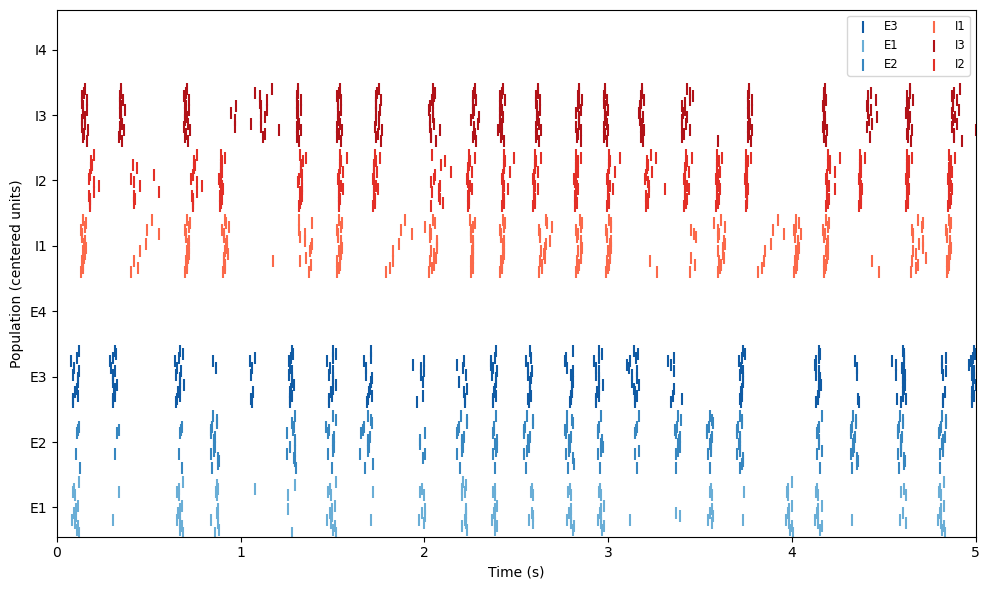

In [522]:
# =============================================================================
# 8. Plot raster and population activity
# =============================================================================

# Initialize a single panel figure specifically for the stacked raster plot
fig, ax_raster = plt.subplots(figsize=(10, 6))

# Build lookup (chip,core,neuron) -> (label, pop_index, unit_index)
pop_map = {}
for pidx, pop in enumerate(exc_neuron_ids):
    for uidx, (chip, core, nid) in enumerate(pop):
        pop_map[(chip, core, nid)] = ("E", pidx, uidx)
for pidx, pop in enumerate(inh_neuron_ids):
    for uidx, (chip, core, nid) in enumerate(pop):
        pop_map[(chip, core, nid)] = ("I", pidx, uidx)

# Ordered populations and stacked baseline positions
pop_order = [("E", i) for i in range(len(exc_neuron_ids))] + [("I", i) for i in range(len(inh_neuron_ids))]
base_by_pop = {}
cum = 0
gap = 3
for label, pidx in pop_order:
    size = len(exc_neuron_ids[pidx]) if label == "E" else len(inh_neuron_ids[pidx])
    base_by_pop[(label, pidx)] = cum
    cum += size + gap

# Collect spikes per population (time, y)
from collections import defaultdict
plot_bins = defaultdict(lambda: {"t": [], "y": []})
for evt in events:
    key = (evt.chip_id, evt.core_id, evt.neuron_id)
    info = pop_map.get(key)
    if info is None:
        continue
    label, pidx, uidx = info
    base = base_by_pop[(label, pidx)]
    plot_bins[(label, pidx)]["t"].append(evt.timestamp * 1e-6)
    plot_bins[(label, pidx)]["y"].append(base + uidx)

# Color maps
colors_E = plt.cm.Blues(np.linspace(0.5, 1.0, max(1, len(exc_neuron_ids))))
colors_I = plt.cm.Reds(np.linspace(0.5, 1.0, max(1, len(inh_neuron_ids))))

# Plot onto ax_raster
for (label, pidx), data in plot_bins.items():
    if not data["t"]:
        continue
    c = colors_E[pidx % len(colors_E)] if label == "E" else colors_I[pidx % len(colors_I)]
    ax_raster.scatter(data["t"], data["y"], marker="|", c=[c], s=80, label=f"{label}{pidx+1}")

# Ticks/labels/limits
yticks = []
ylabels = []
for label, pidx in pop_order:
    base = base_by_pop[(label, pidx)]
    size = len(exc_neuron_ids[pidx]) if label == "E" else len(inh_neuron_ids[pidx])
    center = base + (size - 1) / 2
    yticks.append(center)
    ylabels.append(f"{label}{pidx+1}")

ax_raster.set_yticks(yticks)
ax_raster.set_yticklabels(ylabels)
ax_raster.set_xlabel("Time (s)")
ax_raster.set_ylabel("Population (centered units)")
ax_raster.set_xlim(0, D)
ax_raster.set_ylim(-1, cum)
#ax_raster.set_title("Raster — populations stacked (E: blue, I: red)")
ax_raster.legend(loc="upper right", ncol=2, fontsize="small")

plt.tight_layout()
#plt.savefig('./figures/noise.svg')
plt.show()

In [514]:
from scipy.stats import t

def grubbs_like_test_winners(counts):
    counts = np.array(counts)
    n = len(counts)
    results = []

    for i in range(n):
        others = np.delete(counts, i)
        mean = others.mean()
        std = others.std(ddof=1)

        if std == 0:
            t_score = np.inf if counts[i] > mean else 0
        else:
            t_score = (counts[i] - mean) / std

        # One-tailed test: only look for unusually HIGH counts
        df = len(others) - 1
        p = 1 - t.cdf(t_score, df=df)

        results.append(p)

    return results

def get_winner(plot_bins, n_exc_pops, time=20.0, window=1.0):
    if time - window < 0:
        print("Warning: selection time early after simulation start. Shorter span of considered spike times.")
    
    t_min = max(0, time - window)
    t_max = time

    counts = []
    
    # Iterate directly through the Excitatory populations using the dictionary keys
    for pidx in range(n_exc_pops):
        # Extract the spike times ("t") for this specific excitatory population
        pop_times = np.array(plot_bins[("E", pidx)]["t"])
        
        # Filter and count how many spikes fall within the time window
        valid_spikes = pop_times[(pop_times > t_min) & (pop_times <= t_max)]
        counts.append(len(valid_spikes))

    # Apply the corrected Grubbs-like test (using the fixed version from earlier)
    p_vals_uncorrected = np.array(grubbs_like_test_winners(counts))
    
    # Apply Bonferroni correction and cap at 1.0
    p_vals_bonf = np.clip(p_vals_uncorrected * len(counts), 0.0, 1.0)
        
    return p_vals_bonf

# --- Usage ---
# Assuming 'plot_bins' is your dictionary and you have 4 excitatory populations
p_vals = get_winner(plot_bins, n_exc_pops=len(exc_neuron_ids), time=5.0, window=1.0)
print(p_vals[0])

5.39438579396645e-05


In [ ]:
# Code snippet to add a new cell for per-population rates
fs = 200  # Sampling frequency (Hz)
n_bins = int(D * fs)
time_axis = np.arange(n_bins) / fs

binned_E = np.zeros((N_POPULATIONS, n_bins))
binned_I = np.zeros((N_POPULATIONS, n_bins))

# Build unit-to-population maps for quick lookup
e_map = {unit: pidx for pidx, pop in enumerate(exc_neuron_ids) for unit in pop}
i_map = {unit: pidx for pidx, pop in enumerate(inh_neuron_ids) for unit in pop}

for evt in events:
    t = evt.timestamp * 1e-6
    if t >= D:
        continue
    key = (evt.chip_id, evt.core_id, evt.neuron_id)
    if key in e_map:
        binned_E[e_map[key], int(t * fs)] += 1
    elif key in i_map:
        binned_I[i_map[key], int(t * fs)] += 1

# Convert counts to actual firing rates (Hz) per neuron
bin_width = 1.0 / fs
for i in range(N_POPULATIONS):
    binned_E[i] /= (bin_width * len(exc_neuron_ids[i]))
    binned_I[i] /= (bin_width * len(inh_neuron_ids[i]))

# Smooth with a normalized Gaussian kernel
sigma = 0.01
x_kernel = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-(x_kernel ** 2) / sigma)
gauss /= gauss.sum()  # Ensures firing rate scale is preserved

fig, axes = plt.subplots(N_POPULATIONS, 1, figsize=(12, 8), sharex=True)
for i in range(N_POPULATIONS):
    sm_E = np.convolve(binned_E[i], gauss, 'same')
    sm_I = np.convolve(binned_I[i], gauss, 'same')
    axes[i].plot(time_axis, sm_E, label=f'Exc Pop {i+1}', color='dodgerblue')
    axes[i].plot(time_axis, sm_I, label=f'Inh Pop {i+1}', color='crimson')
    axes[i].axvline(x=duration, color='black', linestyle=':', alpha=0.5, label='Stimulus End')
    axes[i].set_ylabel('Rate (Hz)')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].set_title(f'Population {i+1} Dynamics')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('per_population_rates.png')
plt.show()

In [ ]:
# =============================================================================
# New Section: Cross-Correlation Function (CCF) Analysis
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract Reference Spike Train
ref_spikes = np.array([t for t, idx in zip(all_times, all_indices) if idx == ref_fpga_id])

# 2. Extract Spikes for each Excitatory Population
exc_pop_spikes = {i: [] for i in range(N_POPULATIONS)}
for evt in events:
    key = (evt.chip_id, evt.core_id, evt.neuron_id)
    if key in pop_map:
        label, pidx, uidx = pop_map[key]
        if label == "E":
            exc_pop_spikes[pidx].append(evt.timestamp * 1e-6)

for i in range(N_POPULATIONS):
    exc_pop_spikes[i] = np.array(exc_pop_spikes[i])

# -----------------------------------------------------------------------------
# Function to Compute Spike-Time Cross-Correlogram (CCH)
# -----------------------------------------------------------------------------
def compute_spike_cch(ref, target, max_lag=0.1, bin_width=0.002):
    if len(ref) == 0 or len(target) == 0:
        bins = np.arange(-max_lag, max_lag + bin_width, bin_width)
        return np.zeros(len(bins) - 1), bins
    
    ref_sorted = np.sort(ref)
    target_sorted = np.sort(target)
    
    diffs = []
    # Efficient windowed search for pairwise time differences
    for r_t in ref_sorted:
        idx_start = np.searchsorted(target_sorted, r_t - max_lag)
        idx_end = np.searchsorted(target_sorted, r_t + max_lag)
        for t_t in target_sorted[idx_start:idx_end]:
            diffs.append(t_t - r_t)
            
    bins = np.arange(-max_lag, max_lag + bin_width, bin_width)
    counts, _ = np.histogram(diffs, bins=bins)
    
    # Normalize to Coincidence Rate (Hz) = counts / (N_ref * bin_width)
    coincidence_rate = counts / (len(ref) * bin_width)
    return coincidence_rate, bins

# -----------------------------------------------------------------------------
# Plotting the Results
# -----------------------------------------------------------------------------
# Create a 2x4 multi-panel figure for all 4 populations
fig, axes = plt.subplots(2, N_POPULATIONS, figsize=(20, 8), sharex='row')

colors = plt.cm.Blues(np.linspace(0.6, 1.0, N_POPULATIONS))
max_lag_seconds = 0.1
bin_sz = 0.002

# --- Row 1: High-Resolution Spike-Time CCH ---
for i in range(N_POPULATIONS):
    ax = axes[0, i]
    cch, bins = compute_spike_cch(ref_spikes, exc_pop_spikes[i], max_lag=max_lag_seconds, bin_width=bin_sz)
    bin_centers = bins[:-1] + bin_sz / 2
    
    ax.bar(bin_centers, cch, width=bin_sz, color=colors[i], edgecolor='none', alpha=0.85)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'Pop E{i+1} Spike-Time CCH')
    if i == 0:
        ax.set_ylabel('Coincidence Rate (Hz)')
    ax.set_xlabel('Time Lag $\\tau$ (s)')
    ax.grid(True, alpha=0.2)

# --- Row 2: Macro-Scale Firing Rate CCF ---
# Re-bin the data globally to do a standard normalized signal cross-correlation
fs_ccf = 100
n_bins_ccf = int(D * fs_ccf)
lags_to_check = int(5 * fs_ccf)  # check lags up to +/- 5 seconds

ref_binned = np.zeros(n_bins_ccf)
for t in ref_spikes:
    if t < D: ref_binned[int(t * fs_ccf)] += 1

for i in range(N_POPULATIONS):
    ax = axes[1, i]
    pop_binned = np.zeros(n_bins_ccf)
    for t in exc_pop_spikes[i]:
        if t < D: pop_binned[int(t * fs_ccf)] += 1
        
    # Subtract mean to evaluate covariance/correlation
    ref_centered = ref_binned - np.mean(ref_binned)
    pop_centered = pop_binned - np.mean(pop_binned)
    
    # Compute cross-correlation profile
    ccf_signal = np.correlate(pop_centered, ref_centered, mode='same')
    
    # Normalize by auto-correlation at zero lag to obtain coefficients between -1 and 1
    norm_factor = np.sqrt(np.sum(ref_centered**2) * np.sum(pop_centered**2))
    if norm_factor > 0:
        ccf_signal = ccf_signal / norm_factor
        
    # Extract the center window corresponding to our lag range
    center_idx = len(ccf_signal) // 2
    display_ccf = ccf_signal[center_idx - lags_to_check : center_idx + lags_to_check]
    lag_axis = np.arange(-lags_to_check, lags_to_check) / fs_ccf
    
    ax.plot(lag_axis, display_ccf, color=colors[i], lw=2)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'Pop E{i+1} Rate Tracking CCF')
    if i == 0:
        ax.set_ylabel('Cross-Correlation Coeff.')
    ax.set_xlabel('Time Lag $\\tau$ (s)')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('network_ccf_analysis.png', dpi=300)
plt.show()

In [ ]:
# =============================================================================
# Optional: plot scheduled input/reference spike trains
# =============================================================================
input_spike_times= [t for t, idx in zip(all_times, all_indices) if idx == ref_fpga_id]
plt.figure(figsize=(10, 3))

y_positions = {
    "Ch1": 1,
    "Ch2": 2,
    "Ch3": 3,
    "Ch4": 4,
    "Ref": 5,
}

for name, times in input_spike_times.items():
    plt.scatter(
        times,
        np.ones_like(times) * y_positions[name],
        marker="|",
        s=100,
        label=name,
    )

plt.yticks(
    [1, 2, 3, 4, 5],
    ["Ch1", "Ch2", "Ch3", "Ch4", "Ref"],
)

plt.xlabel("Time (s)")
plt.ylabel("Spike generator")
plt.title(
    f"Correlation filtering validation: Ch{correlated_channel + 1} aligned with reference"
)
plt.xlim(0, duration)
plt.grid(True, axis="x", alpha=0.3)
plt.legend(loc="upper right")
plt.show()

In [ ]:
# =============================================================================
# 9. Optional: save current hardware parameters
# =============================================================================

ut.save_parameters2txt_file(model.get_configuration(), filename='network_parameters_with_inh4.txt')
#ut.save_parameters2json_file(model.get_configuration(), filename='network_parameters_with_inh3.json')


In [ ]:
# =============================================================================
# 10. Optional: reset all DYNAP-SE1 bias parameters to zero
# =============================================================================

"""from dynapse1constants import BIAS_NAMES

for chip in range(4):
    for core in range(4):
        for bias_name in BIAS_NAMES:
            zero_parameter = dyn1.Dynapse1Parameter(bias_name, 0, 0)
            model.update_single_parameter(zero_parameter, chip, core)"""


## Parameter reference notes

The original final cell contained scratch code and unfinished debug snippets. It has been converted into notes so it will not accidentally run with undefined variables.

Useful parameter examples:

| Purpose | Parameter | Example `(coarse, fine)` |
|---|---:|---:|
| Threshold / neuron gain | `IF_THR_N` | `(6, 40)` |
| Refractory period | `IF_RFR_N` | `(3, 50)` |
| Leak / membrane time constant | `IF_TAU1_N` | `(5, 170)` |
| Secondary leak term | `IF_TAU2_N` | `(0, 0)` |
| DC current | `IF_DC_P` | `(0, 0)` |
| Fast excitatory AMPA tau | `NPDPIE_TAU_F_P` | `(4, 80)` |
| Fast excitatory AMPA threshold | `NPDPIE_THR_F_P` | `(0, 0)` |
| Fast excitatory AMPA weight | `PS_WEIGHT_EXC_F_N` | `(0, 0)` |
| Slow excitatory NMDA tau | `NPDPIE_TAU_S_P` | `(4, 80)` |
| Slow excitatory NMDA threshold | `NPDPIE_THR_S_P` | `(0, 0)` |
| Slow excitatory NMDA weight | `PS_WEIGHT_EXC_S_N` | `(0, 0)` |
| NMDA neuron parameter | `IF_NMDA_N` | `(6, 148)` |
| Fast inhibitory GABA_A tau | `NPDPII_TAU_F_P` | `(4, 80)` |

Suggested debug checks, if needed later:

```python
all_event_neuron_ids = [evt.neuron_id for evt in events]
all_event_chip_ids = [evt.chip_id for evt in events]
all_event_core_ids = [evt.core_id for evt in events]

print("All unique neuron IDs in events:", sorted(set(all_event_neuron_ids)))
print("Chips present:", sorted(set(all_event_chip_ids)))
print("Cores present:", sorted(set(all_event_core_ids)))
```
